# 02 - Split, Engenharia de Features e Baseline

**O que este notebook faz:** separa treino/teste ANTES de qualquer transformação (evita vazamento de dados), constrói as features de anomalia (desvio de preço vs. mediana do grupo estado+produto, ajustada só no treino), treina um modelo baseline (IsolationForest) e salva tudo (`referencia`, `preprocessador`, `baseline`) para os próximos notebooks reaproveitarem exatamente o mesmo pipeline.

Continuação de `01_EDA.ipynb`, cuja conclusão principal foi: preço bruto não serve como feature de anomalia porque varia demais entre estados e produtos.

## 1. Imports

In [1]:
import sys
sys.path.append('..')

import os
import joblib  # serializa preprocessador/modelos para reuso nos próximos notebooks
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

from src.data import carregar_dados
from src.features import ReferenciaPrecos, construir_preprocessador
from src.models import prever_anomalias

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

## 2. Carregar os dados

In [2]:
CAMINHO_DADOS = '../data/precos_combustiveis_anp_2025-12.csv'

df = carregar_dados(CAMINHO_DADOS)
df.shape

(52336, 10)

## 3. Split treino/teste — ANTES de qualquer transformação

Estratificamos por `produto` para manter a mesma proporção de gasolina/etanol/gasolina aditivada nos dois conjuntos (na EDA vimos que essa proporção já é razoavelmente equilibrada: ~38/32/30%). Nenhuma estatística (mediana, escala, encoding) é calculada ainda — isso só acontece depois do split, e sempre ajustado (`fit`) apenas no treino, para não vazar informação do teste para o treino.

In [3]:
treino, teste = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df['produto']
)
print('Treino:', treino.shape)
print('Teste :', teste.shape)

Treino: (39252, 10)
Teste : (13084, 10)


In [4]:
# Guardamos o split bruto (antes das features) para os próximos notebooks
# reproduzirem exatamente os mesmos conjuntos, sem precisar repetir o
# train_test_split (e arriscar usar outra seed/proporção por engano).
treino.to_csv('../data/treino.csv', index=False)
teste.to_csv('../data/teste.csv', index=False)

**Resultado:** 39.252 linhas no treino e 13.084 no teste (75/25), com a mesma proporção de produtos da base completa.

## 4. Engenharia de features

A feature mais informativa para este problema não é o preço bruto, e sim o **desvio percentual em relação à mediana do grupo (estado + produto)** — vimos na EDA que o preço 'normal' varia muito por região e produto (ex.: mediana da gasolina R$ 5,79 no Piauí vs. R$ 7,39 no Acre). As medianas de referência são calculadas com `ReferenciaPrecos.fit(treino)` e só depois aplicadas ao teste (`.transform`), para não vazar informação do teste.

In [5]:
referencia = ReferenciaPrecos().fit(treino)

treino_feat = referencia.transform(treino)
teste_feat = referencia.transform(teste)

treino_feat[['valor_venda', 'desvio_pct_estado_produto', 'desvio_pct_brasil_produto']].describe()

,valor_venda,desvio_pct_estado_produto,desvio_pct_brasil_produto
count,39252.000000,39252.000000,39252.000000
mean,5.727162,0.006092,0.004178
std,0.908908,0.056083,0.069500
min,3.490000,-0.207891,-0.222717
25%,4.790000,-0.023866,-0.044543
50%,5.990000,0.000000,0.000000
75%,6.390000,0.033389,0.043818
max,9.590000,0.550918,0.500808


**Resultado:** o desvio percentual fica concentrado perto de zero (mediana 0, desvio-padrão ~5,6% em relação ao estado e ~7,0% em relação ao Brasil), com cauda indo até ~55% acima da mediana — exatamente o tipo de feature com escala comparável entre estados e produtos que faltava ao usar só o preço bruto.

## 5. Preprocessador (padronização + one-hot) — ajustado só no treino

In [6]:
preprocessador = construir_preprocessador()

X_treino = preprocessador.fit_transform(treino_feat)
X_teste = preprocessador.transform(teste_feat)

print('X_treino:', X_treino.shape)
print('X_teste :', X_teste.shape)

X_treino: (39252, 9)
X_teste : (13084, 9)


**Resultado:** 9 colunas na matriz final (3 numéricas padronizadas + 6 dummies de `produto`/`regiao` com `drop='first'`) — dimensão pequena o suficiente para todos os 4 modelos do notebook 03 rodarem rápido, inclusive o OneClassSVM.

## 6. Baseline: IsolationForest

### Como o algoritmo funciona

IsolationForest não aprende "o formato do normal" (como uma gaussiana) — ele tenta **isolar** cada ponto o mais rápido possível e mede quão fácil isso foi. Cada árvore da floresta é construída assim: escolhe uma feature aleatória, escolhe um valor de corte aleatório entre o mínimo e o máximo dessa feature, e particiona os dados; repete recursivamente até cada ponto ficar sozinho em uma folha (ou atingir a profundidade máxima).

A intuição central: um ponto anômalo está "longe" da massa de dados normais em pelo menos uma dimensão, então poucos cortes aleatórios já bastam para isolá-lo — ele fica em uma folha **rasa** (perto da raiz). Um ponto normal, cercado por muitos vizinhos parecidos, precisa de muito mais cortes para ser separado de todo mundo — fica em uma folha **profunda**. O `score_amostra` de cada ponto é o comprimento médio do caminho até isolá-lo, calculado sobre as `n_estimators=200` árvores da floresta e normalizado contra o comprimento esperado de uma busca sem sucesso numa árvore binária balanceada (fórmula de Liu, Ting & Zhou, 2008): caminho curto -> score alto -> mais anômalo.

Vantagens práticas para este problema: não exige que `valor_venda`/os desvios sigam distribuição normal (o que a EDA já mostrou que não seguem), e escala bem com `n` (complexidade média O(n log n)), diferente do OneClassSVM que veremos no notebook 03.

### Por que começar com `contamination=0.02`

`contamination` diz ao modelo "que fração dos dados de treino devo tratar como anomalia ao decidir o limiar de corte do score". Não é um número arbitrário aqui — ele parte direto da triangulação feita na EDA (`01_EDA.ipynb`, seção 8), onde três métodos univariados discordaram sobre a taxa exata mas convergiram numa faixa:

| Método (EDA) | % marcada como anomalia |
|---|---|
| Z-score clássico (média/desvio) | 0,76% |
| Z-score robusto (mediana/MAD) | 1,81% |
| Cercas de Tukey (IQR) | 2,93% |

`contamination=0.02` (2%) fica propositalmente no meio dessa faixa — mais próximo da estimativa robusta (1,81%) que já sabemos ser mais confiável que a clássica (que sofre do efeito de mascaramento discutido na EDA), mas com uma margem para o lado do Tukey, já que aqueles métodos só olham `valor_venda` isoladamente por grupo, enquanto o IsolationForest usa várias features ao mesmo tempo e pode revelar mais anomalias multivariadas (ex.: combinações de preço + região + produto estranhas que não aparecem como outlier univariado). E, de qualquer forma, é uma estimativa inicial: o valor exato só pode ser validado com um rótulo de verdade, que este notebook ainda não tem — isso é feito no notebook `04_avaliacao_tuning`, testando uma grade de valores de `contamination` contra anomalias sintéticas com rótulo conhecido.

In [7]:
baseline = IsolationForest(contamination=0.02, n_estimators=200, random_state=42)
baseline.fit(X_treino)

rotulo_teste, score_teste = prever_anomalias(baseline, X_teste)
print('Anomalias no teste:', rotulo_teste.sum(), '/', len(rotulo_teste))

Anomalias no teste: 247 / 13084


## 7. Inspecionar as anomalias apontadas pelo baseline

In [8]:
resultado = teste_feat.copy()
resultado['anomalia'] = rotulo_teste
resultado['score_anomalia'] = score_teste

colunas_mostrar = ['estado', 'municipio', 'revenda', 'produto', 'valor_venda',
                   'desvio_pct_estado_produto', 'bandeira', 'score_anomalia']
resultado.sort_values('score_anomalia', ascending=False)[colunas_mostrar].head(15)

,estado,municipio,revenda,produto,valor_venda,desvio_pct_estado_produto,bandeira,score_anomalia
2654,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.185980,IPIRANGA,0.083033
5531,AM,PARINTINS,F.J. COMERCIO DE COMBUSTIVEIS LTDA,GASOLINA ADITIVADA,8.29,0.185980,BRANCA,0.083033
6088,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.185980,IPIRANGA,0.083033
8281,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.185980,IPIRANGA,0.083033
3317,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.185980,ATEM' S,0.083033
5869,AM,PARINTINS,F.J. COMERCIO DE COMBUSTIVEIS LTDA,GASOLINA ADITIVADA,8.29,0.185980,BRANCA,0.083033
9586,SP,BARUERI,FGN COMERCIAL LTDA,GASOLINA ADITIVADA,9.49,0.508744,VIBRA,0.079915
715,SP,BARUERI,CENTRO AUTOMOTIVO ALPHA CENTER LTDA,GASOLINA ADITIVADA,9.49,0.508744,VIBRA,0.079915
12650,SP,BARUERI,POSTO DE SERVICOS DUQUE ALPHAVILLE LTDA,GASOLINA ADITIVADA,9.29,0.476948,VIBRA,0.079915
7846,AM,PARINTINS,F.J. COMERCIO DE COMBUSTIVEIS LTDA,GASOLINA,8.29,0.185980,BRANCA,0.074197


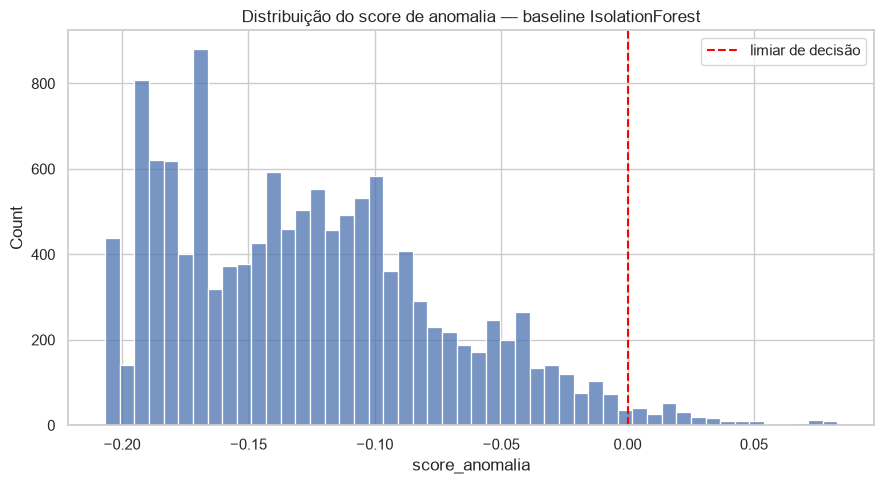

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(resultado['score_anomalia'], bins=50, ax=ax)
ax.axvline(0, color='red', ls='--', label='limiar de decisão')
ax.set_title('Distribuição do score de anomalia — baseline IsolationForest')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/baseline_distribuicao_score.png', dpi=120)
plt.show()

**Resultado:** o baseline aponta 247 anomalias no teste (~1,9%, próximo do `contamination` configurado). Municípios como Parintins (AM) aparecem repetidas vezes no topo do ranking — sinal de que alguns postos/regiões específicas concentram desvios de preço persistentes, e não só ruído aleatório pontual. O histograma do score mostra a maioria dos pontos claramente do lado 'normal' (score negativo) do limiar em zero, com uma cauda curta de scores altos — o padrão esperado para um problema de anomalias raras.

## 8. Salvar preprocessador e modelo baseline

Salvamos `referencia` (medianas) e `preprocessador` junto do modelo porque qualquer dado novo precisa passar pelas MESMAS transformações ajustadas no treino antes de ser avaliado.

In [10]:
joblib.dump(referencia, '../models/referencia_precos.joblib')
joblib.dump(preprocessador, '../models/preprocessador.joblib')
joblib.dump(baseline, '../models/baseline_isolation_forest.joblib')
print('Salvo em ../models/')

Salvo em ../models/


## 9. Próximos passos

- `03_modelagem_comparacao.ipynb`: comparar o IsolationForest com LocalOutlierFactor, OneClassSVM e EllipticEnvelope.
- `04_avaliacao_tuning.ipynb`: injetar anomalias sintéticas no teste para medir precision/recall de verdade e ajustar hiperparâmetros.